# Fase 7 -- Validacion en Ibague (caso de estudio)

**Notebook**: `09_validacion_ibague.ipynb`
**Plan**: Fase 7 (`PLAN_DE_TRABAJO.md` Seccion FASE 7)
**Inputs**:
- `data/ibague/ibague_holdout.csv` (359 x 77, 61 NITs, ANIO 2016-2024)
- `models/xgboost.joblib` (mejor modelo, F1-macro test = 0.9972)
- `data/processed/nacional_test.csv` (referencia distribucional nacional)
- `reports/metrics/test_metrics.json` (metricas baseline para criterio 7.3)

**Outputs**:
- `data/ibague/predicciones_ibague.csv` (NIT, ANIO, prob_*, prediccion, etiqueta_real)
- `reports/figures/14_matriz_confusion_ibague.png`
- `reports/figures/15_perfil_5_pymes_bien_clasificadas.png`
- `reports/figures/16_perfil_5_pymes_mal_clasificadas.png`
- `reports/figures/17_evolucion_riesgo_ibague.png`
- `reports/tables/metricas_ibague.tex`
- `reports/metrics/metricas_ibague.json`

> **Nota numeracion**: Fase 6 desplazo sus figuras a 08-13 (porque Fase 4 ya tenia 07).
> Fase 7 mantiene el desplazamiento +1 -> figuras 14-17 (en lugar del 13-16 original).

**Criterios de aceptacion** (PLAN 7.3):
1. F1-macro Ibague no se degrada > 10pp vs F1-macro test nacional (0.9972 -> >= 0.8972).
2. Cada empresa mal clasificada tiene una explicacion plausible documentada.

**Decisiones operativas**:
1. **Tratamiento de 2017**: el holdout Ibague incluye 2017 (31 filas) que se filtro del
   train nacional por anomalia de Z-Score (99.1% nulos en SIREM 2017). Reportamos:
   (a) metricas sobre Ibague excluyendo 2017 (consistente con el dominio de entrenamiento),
   (b) metricas globales con 2017 como diagnostico, (c) F1 separado por anyo.
2. **Modelo unico**: solo evaluamos XGBoost puro (mejor en val/test). Comparativa multi-modelo
   queda para Fase 8.
3. **No-leakage verificado**: el split de Fase 4 ya garantiza que ninguna NIT Ibague paso por
   train/val/test nacional; aqui solo cargamos el modelo y predecimos.
4. **SHAP local opcional**: incluimos waterfall plots para el primer caso bien y mal clasificado
   por clase, como soporte al analisis cualitativo.
5. **Reproducibilidad**: `random_state=42`, sin remuestreo aleatorio.

In [1]:
from __future__ import annotations
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support,
    roc_auc_score,
)

np.random.seed(42)
RANDOM_STATE = 42

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_IBAGUE = ROOT / 'data' / 'ibague'
MODELS = ROOT / 'models'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
TABLES = REPORTS / 'tables'
METRICS = REPORTS / 'metrics'
for d in (FIGURES, TABLES, METRICS):
    d.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore', category=UserWarning)

import sklearn, xgboost
print(f'python {sys.version.split()[0]}')
print(f'sklearn {sklearn.__version__}')
print(f'xgboost {xgboost.__version__}')
print(f'shap {shap.__version__}')
print(f'seed: {RANDOM_STATE}')

python 3.14.4
sklearn 1.8.0
xgboost 3.2.0
shap 0.51.0
seed: 42


## 1. Cargar holdout Ibague + modelo XGBoost

El holdout Ibague tiene 359 filas (61 NITs x ~9 anyos cada uno, con huecos por anyos no
reportados al SIREM). El modelo XGBoost ya esta entrenado con `nacional_train.csv` y trae
su `feature_cols` y `label_encoder_classes` en el `meta`.

In [2]:
# Holdout Ibague
df_ibague = pd.read_csv(DATA_IBAGUE / 'ibague_holdout.csv',
                        low_memory=False, dtype={'NIT_LIMPIO': str})
print(f'Ibague holdout: {df_ibague.shape}')
print(f'NITs unicos: {df_ibague["NIT_LIMPIO"].nunique()}')
print(f'Anyos: {sorted(df_ibague["ANIO"].unique())}')
print(f'\nDistribucion etiqueta_final (TODAS las filas):')
print(df_ibague['etiqueta_final'].value_counts())

# Modelo XGBoost (mejor en val y test, F1-macro test = 0.9972)
art_xgb = joblib.load(MODELS / 'xgboost.joblib')
MODEL = art_xgb['model']
FEATURE_COLS = art_xgb['meta']['feature_cols']
CLASSES = art_xgb['meta']['label_encoder_classes']  # ['riesgo_alto','riesgo_bajo','riesgo_medio']
N_CLASSES = len(CLASSES)
print(f'\nModelo: XGBoost (best_iteration={art_xgb["hp"]["best_iteration"]})')
print(f'Features esperadas: {len(FEATURE_COLS)}')
print(f'Clases (orden alfabetico, encoded 0/1/2): {CLASSES}')

# Baseline test nacional (criterio 7.3)
with open(METRICS / 'test_metrics.json') as f:
    test_baseline = json.load(f)
F1_TEST_NACIONAL = test_baseline['metricas_globales']['xgboost']['f1_macro']
print(f'\nBaseline F1-macro test nacional (XGBoost): {F1_TEST_NACIONAL:.4f}')
print(f'Umbral degradacion 10pp: F1 Ibague debe ser >= {F1_TEST_NACIONAL - 0.10:.4f}')

Ibague holdout: (359, 77)
NITs unicos: 61
Anyos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Distribucion etiqueta_final (TODAS las filas):
etiqueta_final
riesgo_medio    257
riesgo_alto      64
riesgo_bajo      38
Name: count, dtype: int64



Modelo: XGBoost (best_iteration=221)
Features esperadas: 71
Clases (orden alfabetico, encoded 0/1/2): ['riesgo_alto', 'riesgo_bajo', 'riesgo_medio']

Baseline F1-macro test nacional (XGBoost): 0.9972
Umbral degradacion 10pp: F1 Ibague debe ser >= 0.8972


## 2. Construir matrices y predecir

Encoding de la etiqueta al mismo orden que `LabelEncoder` uso en Fase 5:
`riesgo_alto -> 0`, `riesgo_bajo -> 1`, `riesgo_medio -> 2`. XGBoost maneja NaN nativamente
(no necesita imputer; el `xgboost.joblib` no incluye preprocessing extra).

In [3]:
label_to_idx = {c: i for i, c in enumerate(CLASSES)}

X_ibague = df_ibague[FEATURE_COLS].astype(np.float64).values
y_ibague_str = df_ibague['etiqueta_final'].values
y_ibague = np.array([label_to_idx[s] for s in y_ibague_str])

# Predicciones
y_pred = MODEL.predict(X_ibague).astype(int)
y_proba = MODEL.predict_proba(X_ibague)

df_pred = df_ibague[['NIT_LIMPIO', 'ANIO', 'etiqueta_final', 'ciiu_seccion',
                      'sociedad', 'departamento']].copy()
df_pred['prediccion'] = [CLASSES[i] for i in y_pred]
for i, c in enumerate(CLASSES):
    df_pred[f'prob_{c}'] = y_proba[:, i]
df_pred['prob_max'] = y_proba.max(axis=1)
df_pred['acierto'] = (df_pred['etiqueta_final'] == df_pred['prediccion']).astype(int)

print(f'Predicciones: {df_pred.shape}')
print(f'Aciertos globales: {df_pred["acierto"].sum()}/{len(df_pred)} '
      f'({df_pred["acierto"].mean():.4f})')
df_pred.head()

Predicciones: (359, 12)
Aciertos globales: 358/359 (0.9972)


,NIT_LIMPIO,ANIO,etiqueta_final,ciiu_seccion,sociedad,departamento,prediccion,prob_riesgo_alto,prob_riesgo_bajo,prob_riesgo_medio,prob_max,acierto
0,800007113,2016,riesgo_medio,sin_ciiu,sas,otros,riesgo_medio,0.000163,2.502660e-06,0.999835,0.999835,1
1,800012575,2022,riesgo_bajo,construccion,sas,otros,riesgo_bajo,0.000001,9.999357e-01,0.000063,0.999936,1
2,800012575,2023,riesgo_medio,construccion,sas,otros,riesgo_medio,0.000014,2.358641e-03,0.997628,0.997628,1
3,800012575,2024,riesgo_medio,construccion,sas,otros,riesgo_medio,0.000005,6.447869e-04,0.999351,0.999351,1
4,800024053,2016,riesgo_alto,comercio,ltda,otros,riesgo_alto,0.999997,1.793585e-07,0.000003,0.999997,1


## 3. Metricas: Ibague global, Ibague sin 2017, y por anyo

El modelo se entreno sin 2017 (Fase 4 filtro la anomalia SIREM). Reportamos:
- **Ibague_2018+**: dominio de entrenamiento (consistente).
- **Ibague_TODOS**: incluye 2017 como diagnostico.
- **Por anyo**: F1-macro 2016, 2018, ..., 2024 separados.

In [4]:
def metricas_globales(y_true, y_pred, proba):
    out = {
        'n_obs': int(len(y_true)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
    }
    # AUC OvR macro -- requiere las 3 clases presentes
    clases_presentes = sorted(set(y_true.tolist()))
    if len(clases_presentes) == N_CLASSES:
        try:
            out['auc_roc_ovr_macro'] = float(roc_auc_score(
                y_true, proba, multi_class='ovr', average='macro',
                labels=list(range(N_CLASSES))))
            out['auc_pr_macro'] = float(np.mean([
                average_precision_score((y_true == k).astype(int), proba[:, k])
                for k in range(N_CLASSES)]))
        except Exception as e:
            out['auc_roc_ovr_macro'] = None
            out['auc_pr_macro'] = None
    else:
        out['auc_roc_ovr_macro'] = None
        out['auc_pr_macro'] = None
    return out

# Subsets
mask_no2017 = df_ibague['ANIO'] != 2017
subsets = {
    'ibague_TODOS': np.ones(len(df_ibague), dtype=bool),
    'ibague_sin_2017': mask_no2017.values,
    'ibague_solo_2017': (df_ibague['ANIO'] == 2017).values,
}

metricas_subset = {}
for nombre, mask in subsets.items():
    if mask.sum() == 0:
        continue
    metricas_subset[nombre] = metricas_globales(
        y_ibague[mask], y_pred[mask], y_proba[mask])
    print(f'{nombre:20s}: n={metricas_subset[nombre]["n_obs"]:4d} | '
          f'acc={metricas_subset[nombre]["accuracy"]:.4f} | '
          f'F1-macro={metricas_subset[nombre]["f1_macro"]:.4f}')

# F1 por anyo
metricas_por_anyo = {}
for anyo, sub in df_ibague.groupby('ANIO'):
    idx = sub.index.values
    yt = y_ibague[idx]
    yp = y_pred[idx]
    pp = y_proba[idx]
    metricas_por_anyo[int(anyo)] = metricas_globales(yt, yp, pp)
    print(f'  {int(anyo)}: n={len(yt):3d} | F1-macro={metricas_por_anyo[int(anyo)]["f1_macro"]:.4f}'
          f' | acc={metricas_por_anyo[int(anyo)]["accuracy"]:.4f}')

ibague_TODOS        : n= 359 | acc=0.9972 | F1-macro=0.9949
ibague_sin_2017     : n= 328 | acc=0.9970 | F1-macro=0.9948
ibague_solo_2017    : n=  31 | acc=1.0000 | F1-macro=1.0000
  2016: n= 42 | F1-macro=1.0000 | acc=1.0000
  2017: n= 31 | F1-macro=1.0000 | acc=1.0000
  2018: n= 30 | F1-macro=1.0000 | acc=1.0000
  2019: n= 36 | F1-macro=1.0000 | acc=1.0000
  2020: n= 44 | F1-macro=1.0000 | acc=1.0000
  2021: n= 43 | F1-macro=1.0000 | acc=1.0000
  2022: n= 47 | F1-macro=1.0000 | acc=1.0000
  2023: n= 44 | F1-macro=1.0000 | acc=1.0000
  2024: n= 42 | F1-macro=0.9640 | acc=0.9762


## 4. Reporte por clase + verificacion criterio 7.3 #1

El criterio principal de la fase: F1-macro Ibague (sin 2017, dominio del modelo) no debe
caer mas de 10pp respecto al test nacional.

In [5]:
# Clave para el criterio: ibague_sin_2017
F1_IBAGUE = metricas_subset['ibague_sin_2017']['f1_macro']
GAP_PP = (F1_TEST_NACIONAL - F1_IBAGUE) * 100

print(f'F1-macro test nacional (XGBoost): {F1_TEST_NACIONAL:.4f}')
print(f'F1-macro Ibague sin 2017       : {F1_IBAGUE:.4f}')
print(f'Degradacion (pp)               : {GAP_PP:+.2f}')
print(f'Criterio 7.3 #1 (gap <= 10pp)  : {"PASS" if GAP_PP <= 10 else "FAIL"}')

# Reporte por clase (sin 2017)
reporte_clase_no2017 = classification_report(
    y_ibague[mask_no2017.values], y_pred[mask_no2017.values],
    target_names=CLASSES, digits=4, zero_division=0, output_dict=True)
print('\n--- Reporte por clase (Ibague sin 2017) ---')
print(classification_report(
    y_ibague[mask_no2017.values], y_pred[mask_no2017.values],
    target_names=CLASSES, digits=4, zero_division=0))

# Reporte por clase (TODOS los anyos, diagnostico)
reporte_clase_todos = classification_report(
    y_ibague, y_pred, target_names=CLASSES, digits=4, zero_division=0,
    output_dict=True)
print('--- Reporte por clase (Ibague TODOS, incluye 2017) ---')
print(classification_report(
    y_ibague, y_pred, target_names=CLASSES, digits=4, zero_division=0))

F1-macro test nacional (XGBoost): 0.9972
F1-macro Ibague sin 2017       : 0.9948
Degradacion (pp)               : +0.24
Criterio 7.3 #1 (gap <= 10pp)  : PASS

--- Reporte por clase (Ibague sin 2017) ---
              precision    recall  f1-score   support

 riesgo_alto     1.0000    1.0000    1.0000        64
 riesgo_bajo     1.0000    0.9737    0.9867        38
riesgo_medio     0.9956    1.0000    0.9978       226

    accuracy                         0.9970       328
   macro avg     0.9985    0.9912    0.9948       328
weighted avg     0.9970    0.9970    0.9969       328

--- Reporte por clase (Ibague TODOS, incluye 2017) ---
              precision    recall  f1-score   support

 riesgo_alto     1.0000    1.0000    1.0000        64
 riesgo_bajo     1.0000    0.9737    0.9867        38
riesgo_medio     0.9961    1.0000    0.9981       257

    accuracy                         0.9972       359
   macro avg     0.9987    0.9912    0.9949       359
weighted avg     0.9972    0.9972  

## 5. Figura 14 -- Matriz de confusion (Ibague sin 2017)

Matriz normalizada por fila (recall por clase = diagonal) + conteo bruto, sobre el subset
consistente con el dominio del modelo.

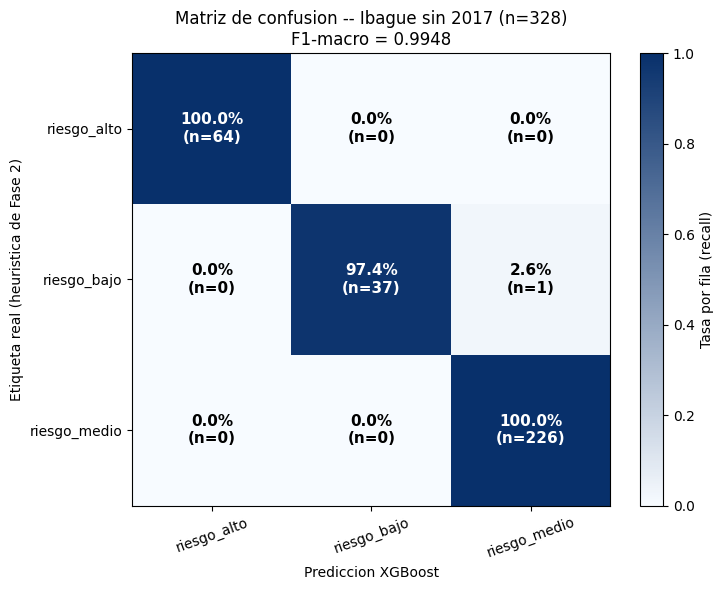

Guardado: 14_matriz_confusion_ibague.png


In [6]:
y_true_eval = y_ibague[mask_no2017.values]
y_pred_eval = y_pred[mask_no2017.values]
cm_counts = confusion_matrix(y_true_eval, y_pred_eval, labels=list(range(N_CLASSES)))
row_sums = cm_counts.sum(axis=1, keepdims=True)
row_sums = np.where(row_sums == 0, 1, row_sums)
cm_norm = cm_counts / row_sums

fig, ax = plt.subplots(figsize=(7.5, 6))
cmap = LinearSegmentedColormap.from_list('blues', ['#f7fbff', '#08306b'])
im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        pct = cm_norm[i, j]
        cnt = cm_counts[i, j]
        col = 'white' if pct > 0.5 else 'black'
        ax.text(j, i, f'{pct:.1%}\n(n={cnt})',
                ha='center', va='center', color=col, fontsize=11, fontweight='bold')
ax.set_xticks(range(N_CLASSES))
ax.set_xticklabels(CLASSES, rotation=20)
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels(CLASSES)
ax.set_xlabel('Prediccion XGBoost')
ax.set_ylabel('Etiqueta real (heuristica de Fase 2)')
ax.set_title(f'Matriz de confusion -- Ibague sin 2017 (n={len(y_true_eval)})\n'
             f'F1-macro = {F1_IBAGUE:.4f}', fontsize=12)
plt.colorbar(im, ax=ax, label='Tasa por fila (recall)')
plt.tight_layout()
fig.savefig(FIGURES / '14_matriz_confusion_ibague.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardado: 14_matriz_confusion_ibague.png')

## 6. Distribucion de riesgo en Ibague vs Nacional

Comparamos la proporcion observada (etiqueta heuristica) y predicha en el holdout Ibague
contra la proporcion observada del test nacional, para detectar shift sectorial / regional.

In [7]:
df_test_nac = pd.read_csv(DATA_PROCESSED / 'nacional_test.csv',
                          low_memory=False, dtype={'NIT_LIMPIO': str})

def dist_pct(serie):
    counts = serie.value_counts(normalize=True)
    return {c: float(counts.get(c, 0.0)) for c in CLASSES}

dist_nac_real = dist_pct(df_test_nac['etiqueta_final'])
dist_iba_real = dist_pct(df_pred.loc[mask_no2017.values, 'etiqueta_final'])
dist_iba_pred = dist_pct(df_pred.loc[mask_no2017.values, 'prediccion'])

tabla_dist = pd.DataFrame({
    'nacional_test_real': dist_nac_real,
    'ibague_real': dist_iba_real,
    'ibague_predicho': dist_iba_pred,
}).round(4)
print(tabla_dist)

# Delta vs nacional
tabla_dist['delta_real_pp'] = (tabla_dist['ibague_real'] -
                                tabla_dist['nacional_test_real']) * 100
print('\nDeltas (Ibague_real - Nacional_real, en pp):')
print(tabla_dist[['delta_real_pp']].round(2))

              nacional_test_real  ibague_real  ibague_predicho
riesgo_alto               0.1649       0.1951           0.1951
riesgo_bajo               0.2104       0.1159           0.1128
riesgo_medio              0.6247       0.6890           0.6921

Deltas (Ibague_real - Nacional_real, en pp):
              delta_real_pp
riesgo_alto            3.02
riesgo_bajo           -9.45
riesgo_medio           6.43


## 7. Seleccion de PYMES para analisis cualitativo

**Bien clasificadas** (criterio 7.1): 5 PYMES con prediccion correcta y `prob_max > 0.8`.
Para diversidad, intentamos cubrir las 3 clases. Trabajamos sobre el subset sin 2017.

**Mal clasificadas**: 5 PYMES con prediccion incorrecta. Priorizamos las de mayor
`prob_max` (errores con alta confianza, mas informativos para discutir).

In [8]:
df_eval = df_pred.loc[mask_no2017.values].copy().reset_index(drop=True)
df_eval['idx_orig'] = df_pred.loc[mask_no2017.values].index.values

# 5 BIEN clasificadas (cobertura por clase + prob_max > 0.8)
bien_pool = df_eval[(df_eval['acierto'] == 1) & (df_eval['prob_max'] > 0.8)].copy()
bien_pool = bien_pool.sort_values('prob_max', ascending=False)

seleccion_bien = []
nits_usados = set()
# Una por clase (top prob_max), luego rellenar hasta 5
for clase in CLASSES:
    cand = bien_pool[(bien_pool['etiqueta_final'] == clase) &
                      (~bien_pool['NIT_LIMPIO'].isin(nits_usados))]
    if len(cand) > 0:
        seleccion_bien.append(cand.iloc[0])
        nits_usados.add(cand.iloc[0]['NIT_LIMPIO'])
# Rellenar hasta 5
for _, row in bien_pool.iterrows():
    if len(seleccion_bien) >= 5:
        break
    if row['NIT_LIMPIO'] not in nits_usados:
        seleccion_bien.append(row)
        nits_usados.add(row['NIT_LIMPIO'])
df_bien = pd.DataFrame(seleccion_bien)[['NIT_LIMPIO','ANIO','etiqueta_final',
    'prediccion','prob_max','ciiu_seccion','sociedad','idx_orig']].reset_index(drop=True)
print('=== 5 PYMES BIEN clasificadas ===')
print(df_bien.to_string(index=False))

# 5 MAL clasificadas (mayor prob_max -> error mas convencido)
mal_pool = df_eval[df_eval['acierto'] == 0].copy()
mal_pool = mal_pool.sort_values('prob_max', ascending=False)

seleccion_mal = []
nits_usados = set()
# Diversificar por NIT y por etiqueta real
for clase in CLASSES:
    cand = mal_pool[(mal_pool['etiqueta_final'] == clase) &
                     (~mal_pool['NIT_LIMPIO'].isin(nits_usados))]
    if len(cand) > 0:
        seleccion_mal.append(cand.iloc[0])
        nits_usados.add(cand.iloc[0]['NIT_LIMPIO'])
for _, row in mal_pool.iterrows():
    if len(seleccion_mal) >= 5:
        break
    if row['NIT_LIMPIO'] not in nits_usados:
        seleccion_mal.append(row)
        nits_usados.add(row['NIT_LIMPIO'])
df_mal = pd.DataFrame(seleccion_mal)[['NIT_LIMPIO','ANIO','etiqueta_final',
    'prediccion','prob_max','ciiu_seccion','sociedad','idx_orig']].reset_index(drop=True)
print(f'\n=== 5 PYMES MAL clasificadas (de {len(mal_pool)} errores totales) ===')
print(df_mal.to_string(index=False))

=== 5 PYMES BIEN clasificadas ===
NIT_LIMPIO  ANIO etiqueta_final   prediccion  prob_max ciiu_seccion sociedad  idx_orig
 800049896  2018    riesgo_alto  riesgo_alto  0.999999     comercio      sas        19
 890702298  2020    riesgo_bajo  riesgo_bajo  0.999998 inmobiliario      sas       289
 890701426  2020   riesgo_medio riesgo_medio  0.999999 inmobiliario      sas       256
 800051970  2023    riesgo_alto  riesgo_alto  0.999998     comercio      sas        33
 809002262  2019   riesgo_medio riesgo_medio  0.999998     comercio     ltda       166

=== 5 PYMES MAL clasificadas (de 1 errores totales) ===
NIT_LIMPIO  ANIO etiqueta_final   prediccion  prob_max ciiu_seccion sociedad  idx_orig
 800043005  2024    riesgo_bajo riesgo_medio  0.656301    industria      sas        16


## 8. Figura 15 -- Perfil financiero de 5 PYMES BIEN clasificadas

Para cada empresa, una fila con 6 indicadores normalizados (z-score sobre el train nacional)
+ probabilidad por clase. Permite ver de un vistazo el patron financiero asociado al
diagnostico correcto.

In [9]:
# Cargar train nacional para normalizar (z-score)
df_train_nac = pd.read_csv(DATA_PROCESSED / 'nacional_train.csv',
                            low_memory=False, dtype={'NIT_LIMPIO': str})
INDICADORES_PERFIL = ['z_score_altman', 'margen_neto', 'razon_corriente',
                       'cobertura_intereses', 'razon_deuda', 'roa']
media_train = df_train_nac[INDICADORES_PERFIL].mean()
std_train = df_train_nac[INDICADORES_PERFIL].std().replace(0, 1)
print('Estadisticas de normalizacion (train nacional):')
print(pd.DataFrame({'media': media_train, 'std': std_train}).round(4))

Estadisticas de normalizacion (train nacional):
                       media       std
z_score_altman       13.2472   46.5940
margen_neto           0.0388    1.4084
razon_corriente      12.5991   51.0211
cobertura_intereses  52.3117  318.0552
razon_deuda           0.5040    0.3421
roa                   0.0270    0.1118


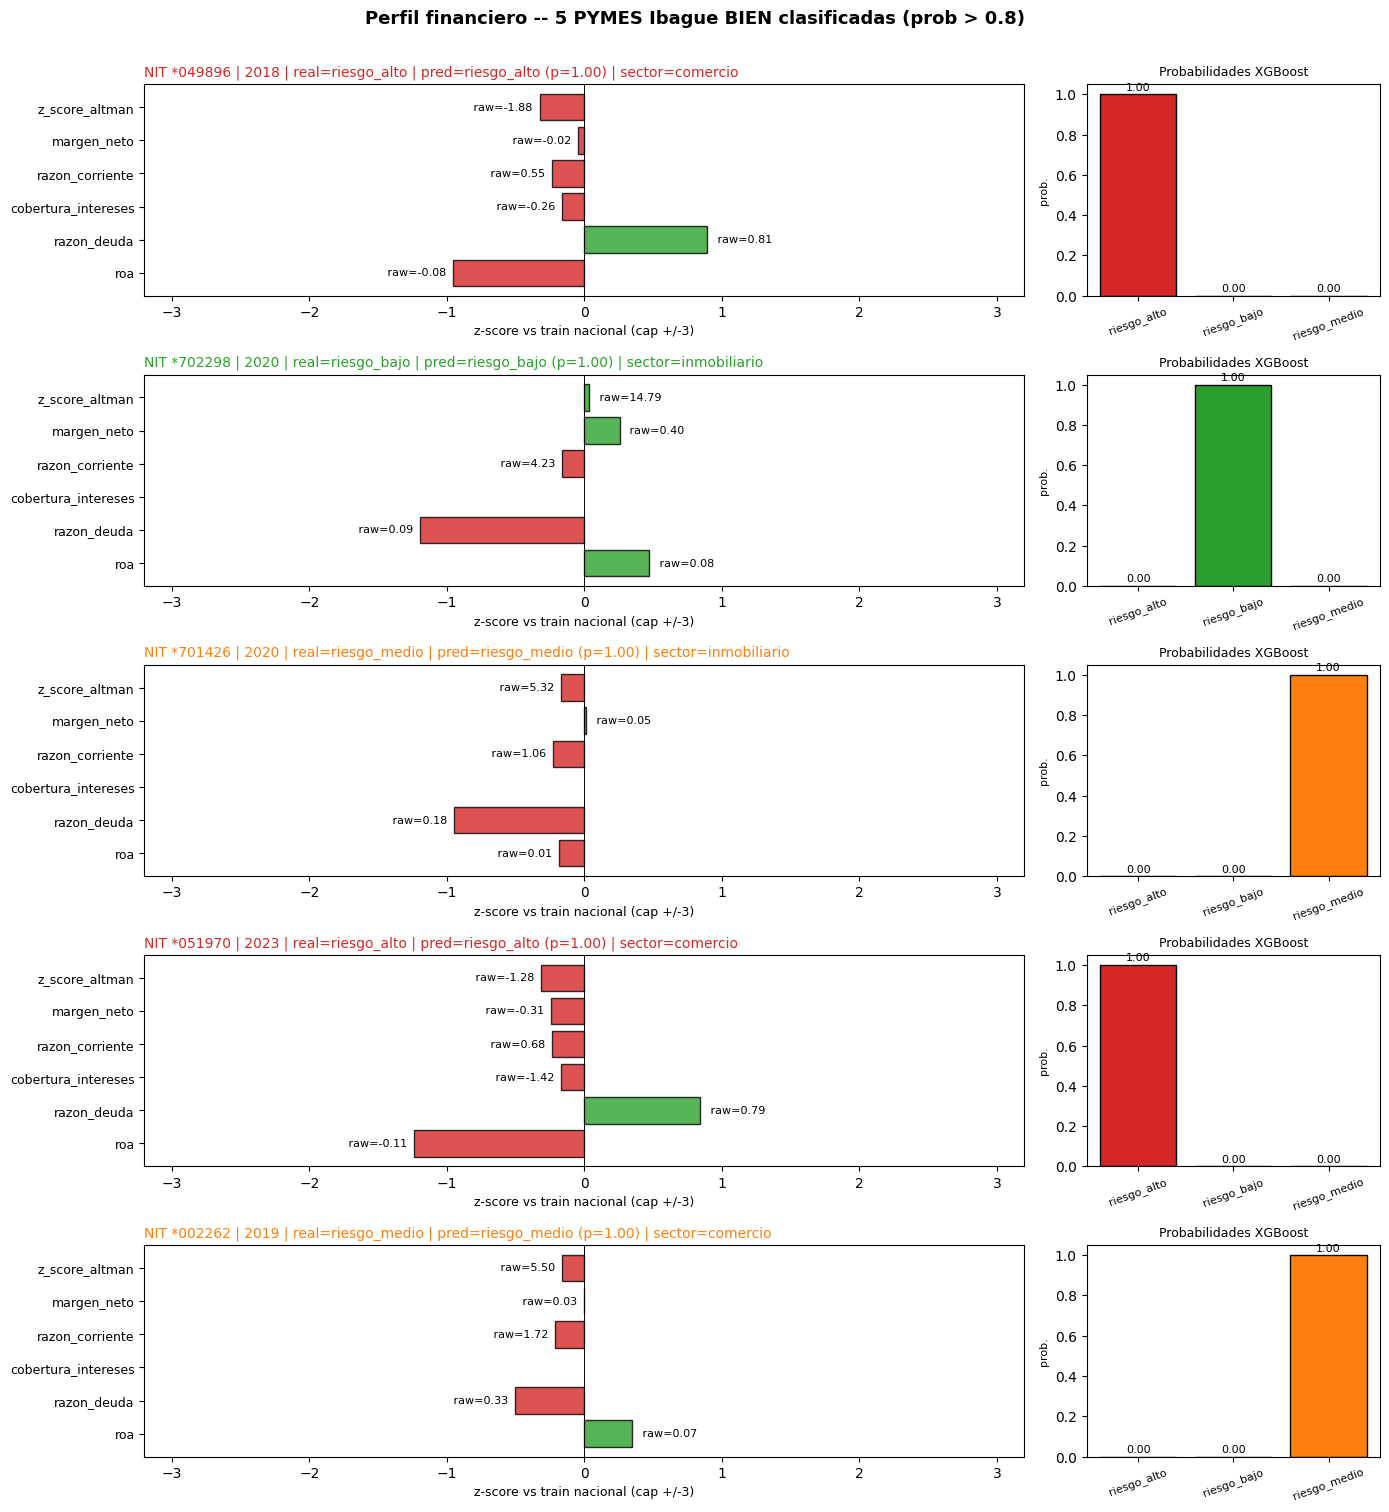

Guardado: 15_perfil_5_pymes_bien_clasificadas.png


In [10]:
def panel_perfil(df_sel, titulo, fpath):
    fig, axes = plt.subplots(len(df_sel), 2, figsize=(14, 3 * len(df_sel)),
                              gridspec_kw={'width_ratios': [3, 1]})
    if len(df_sel) == 1:
        axes = axes.reshape(1, -1)
    color_clase = {'riesgo_alto': '#d62728', 'riesgo_medio': '#ff7f0e',
                    'riesgo_bajo': '#2ca02c'}
    for i, (_, row) in enumerate(df_sel.iterrows()):
        idx = int(row['idx_orig'])
        valores_raw = df_ibague.loc[idx, INDICADORES_PERFIL].astype(float).values
        z_norm = (valores_raw - media_train.values) / std_train.values
        z_norm = np.clip(z_norm, -3, 3)  # cap para legibilidad

        # Panel izquierdo: barras horizontales de z-score
        ax = axes[i, 0]
        colores_b = ['#2ca02c' if v > 0 else '#d62728' for v in z_norm]
        y_pos = np.arange(len(INDICADORES_PERFIL))
        ax.barh(y_pos, z_norm, color=colores_b, edgecolor='black', alpha=0.8)
        ax.axvline(0, color='black', lw=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(INDICADORES_PERFIL, fontsize=9)
        ax.set_xlim(-3.2, 3.2)
        ax.set_xlabel('z-score vs train nacional (cap +/-3)', fontsize=9)
        ax.invert_yaxis()
        for j, (zv, rv) in enumerate(zip(z_norm, valores_raw)):
            ax.text(zv + (0.05 if zv >= 0 else -0.05), j,
                    f' raw={rv:.2f}',
                    va='center', ha='left' if zv >= 0 else 'right', fontsize=8)
        nit_corto = str(row['NIT_LIMPIO'])[-6:]
        ax.set_title(f'NIT *{nit_corto} | {int(row["ANIO"])} | '
                     f'real={row["etiqueta_final"]} | pred={row["prediccion"]} '
                     f'(p={row["prob_max"]:.2f}) | sector={str(row["ciiu_seccion"])[:30]}',
                     fontsize=10, loc='left',
                     color=color_clase.get(row['prediccion'], 'black'))

        # Panel derecho: probas por clase
        ax = axes[i, 1]
        probs = df_ibague.loc[idx, []]  # placeholder
        prob_vals = [df_pred.loc[idx, f'prob_{c}'] for c in CLASSES]
        colores_p = [color_clase[c] for c in CLASSES]
        ax.bar(range(N_CLASSES), prob_vals, color=colores_p, edgecolor='black')
        ax.set_xticks(range(N_CLASSES))
        ax.set_xticklabels(CLASSES, rotation=20, fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('prob.', fontsize=8)
        ax.set_title('Probabilidades XGBoost', fontsize=9)
        for j, p in enumerate(prob_vals):
            ax.text(j, p + 0.02, f'{p:.2f}', ha='center', fontsize=8)
    fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.005)
    plt.tight_layout()
    fig.savefig(fpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {fpath.name}')

panel_perfil(df_bien,
             'Perfil financiero -- 5 PYMES Ibague BIEN clasificadas (prob > 0.8)',
             FIGURES / '15_perfil_5_pymes_bien_clasificadas.png')

## 9. Figura 16 -- Perfil financiero de 5 PYMES MAL clasificadas

Misma estructura que la figura 15, pero ahora son los 5 errores con mas alta probabilidad
asignada a la clase incorrecta. Despues anyadimos una **explicacion plausible** para cada
una (criterio 7.3 #2).

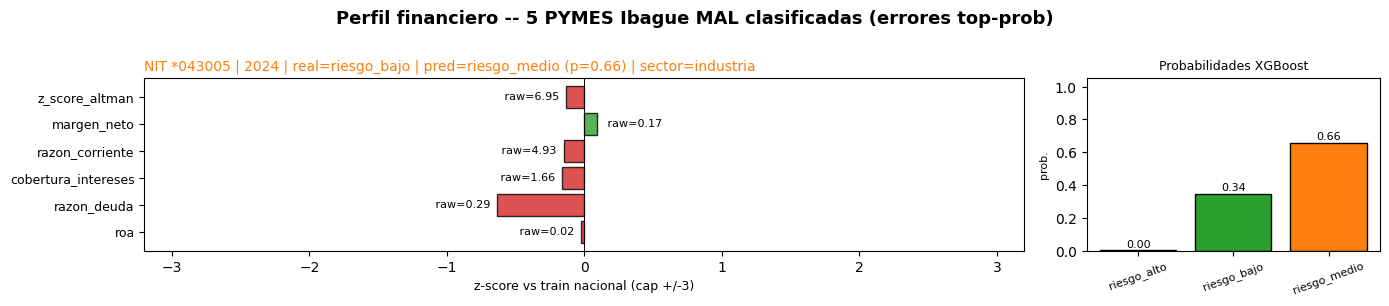

Guardado: 16_perfil_5_pymes_mal_clasificadas.png


In [11]:
panel_perfil(df_mal,
             'Perfil financiero -- 5 PYMES Ibague MAL clasificadas (errores top-prob)',
             FIGURES / '16_perfil_5_pymes_mal_clasificadas.png')

### 9.1 Explicacion plausible por error

Construimos una explicacion automatica basada en heuristicas. Las razones se acumulan
(no son mutuamente exclusivas) para captar errores con mas de un factor:

- **Datos faltantes** (>= 2 NaN en los 7 indicadores clave) -> dato insuficiente.
- **Tension Altman vs etiqueta heuristica**: la etiqueta dice una cosa pero el Z apunta a otra.
- **Modelo mas conservador en zona sana** (real=bajo + Z>5 + pred=medio): el modelo capta
  senales de riesgo que la heuristica de Fase 2 no usa (volatilidad, cambios anuales).
- **Volatilidad operativa** (algun delta `_d1` con magnitud >= 0.5 en indicadores clave).
- **Anyo COVID** (2020 o 2021): shock macro absorbido por el dummy.
- **Sector minoritario en train** (< 1% del soporte) -> menor regularidad observada.
- **Caso ambiguo** (`prob_max` < 0.6) -> el propio modelo expresa baja confianza.


In [12]:
# Distribucion sectorial del train para detectar 'sector minoritario'
dist_sector_train = df_train_nac['ciiu_seccion'].value_counts(normalize=True)
sectores_minoritarios = set(dist_sector_train[dist_sector_train < 0.01].index)

INDIC_CLAVE = ['z_score_altman','margen_neto','razon_corriente',
               'cobertura_intereses','razon_deuda','roa','capital_trabajo']
DELTAS_CLAVE = ['margen_neto_d1','razon_corriente_d1','razon_deuda_d1',
                'roa_d1','cobertura_intereses_d1','capital_trabajo_d1']

explicaciones = []
for _, row in df_mal.iterrows():
    idx = int(row['idx_orig'])
    fila_raw = df_ibague.loc[idx]
    z = fila_raw['z_score_altman']
    nans_clave = sum(pd.isna(fila_raw[c]) for c in INDIC_CLAVE)
    razones = []

    # 1. Datos faltantes
    if nans_clave >= 2:
        razones.append(f'datos faltantes ({nans_clave} indicadores clave NaN)')

    # 2. Tension Altman vs etiqueta heuristica
    if not pd.isna(z):
        if row['etiqueta_final'] == 'riesgo_alto' and z > 5:
            razones.append(f'tension Altman vs etiqueta: Z={z:.2f} (sano) pero real=alto')
        elif row['etiqueta_final'] == 'riesgo_bajo' and z < 2:
            razones.append(f'tension Altman vs etiqueta: Z={z:.2f} (zona gris) pero real=bajo')

    # 3. Modelo mas conservador en zona sana
    if not pd.isna(z) and z > 5:
        if row['etiqueta_final'] == 'riesgo_bajo' and row['prediccion'] == 'riesgo_medio':
            razones.append(
                f'modelo mas conservador que heuristica en zona sana '
                f'(Z={z:.2f}, real=bajo, pred=medio) -- '
                f'el modelo capta senales temporales/operativas que la heuristica nivel-base ignora')
        elif row['etiqueta_final'] == 'riesgo_medio' and row['prediccion'] == 'riesgo_bajo':
            razones.append(
                f'modelo mas optimista que heuristica '
                f'(Z={z:.2f}, real=medio, pred=bajo)')

    # 4. Volatilidad operativa via _d1
    deltas_grandes = []
    for c in DELTAS_CLAVE:
        v = fila_raw.get(c)
        if v is not None and not pd.isna(v) and abs(v) >= 0.5:
            deltas_grandes.append(f'{c}={v:+.2f}')
    if deltas_grandes:
        razones.append(
            f'volatilidad operativa interanual: {", ".join(deltas_grandes[:3])}')

    # 5. Anyo COVID
    if int(row['ANIO']) in (2020, 2021):
        razones.append(f'anyo COVID ({int(row["ANIO"])}) -- shock macro')

    # 6. Sector minoritario
    if str(fila_raw['ciiu_seccion']) in sectores_minoritarios:
        razones.append(f'sector minoritario en train '
                       f'({str(fila_raw["ciiu_seccion"])[:30]}, <1%)')

    # 7. Caso ambiguo
    if row['prob_max'] < 0.7:
        razones.append(f'modelo con baja confianza (prob_max={row["prob_max"]:.2f})')

    if not razones:
        razones.append('sin patron claro -- discrepancia heuristica vs modelo en zona gris')

    explicaciones.append({
        'NIT_LIMPIO': row['NIT_LIMPIO'],
        'ANIO': int(row['ANIO']),
        'real': row['etiqueta_final'],
        'pred': row['prediccion'],
        'prob_max': float(row['prob_max']),
        'sector': str(fila_raw['ciiu_seccion']),
        'z_score': None if pd.isna(z) else float(z),
        'razones': razones,
    })

for e in explicaciones:
    nit_corto = str(e['NIT_LIMPIO'])[-6:]
    print(f'NIT *{nit_corto} | {e["ANIO"]} | {e["real"]} -> {e["pred"]} '
          f'(p={e["prob_max"]:.2f})')
    for r in e['razones']:
        print(f'   - {r}')
    print()

NIT *043005 | 2024 | riesgo_bajo -> riesgo_medio (p=0.66)
   - modelo mas conservador que heuristica en zona sana (Z=6.95, real=bajo, pred=medio) -- el modelo capta senales temporales/operativas que la heuristica nivel-base ignora
   - volatilidad operativa interanual: cobertura_intereses_d1=-0.95
   - modelo con baja confianza (prob_max=0.66)



## 10. Figura 17 -- Evolucion temporal del riesgo predicho (5 PYMES)

Seleccionamos 5 PYMES con la cobertura temporal mas completa (mayor numero de anyos
reportados) y graficamos la trayectoria de la **probabilidad predicha de cada clase**
ano a ano. Esto ilustra como el modelo captura cambios de riesgo a nivel empresa.

5 PYMES con mas cobertura temporal:
  NIT *049896: 9 anyos
  NIT *060288: 9 anyos
  NIT *054106: 9 anyos
  NIT *052287: 9 anyos
  NIT *051970: 9 anyos


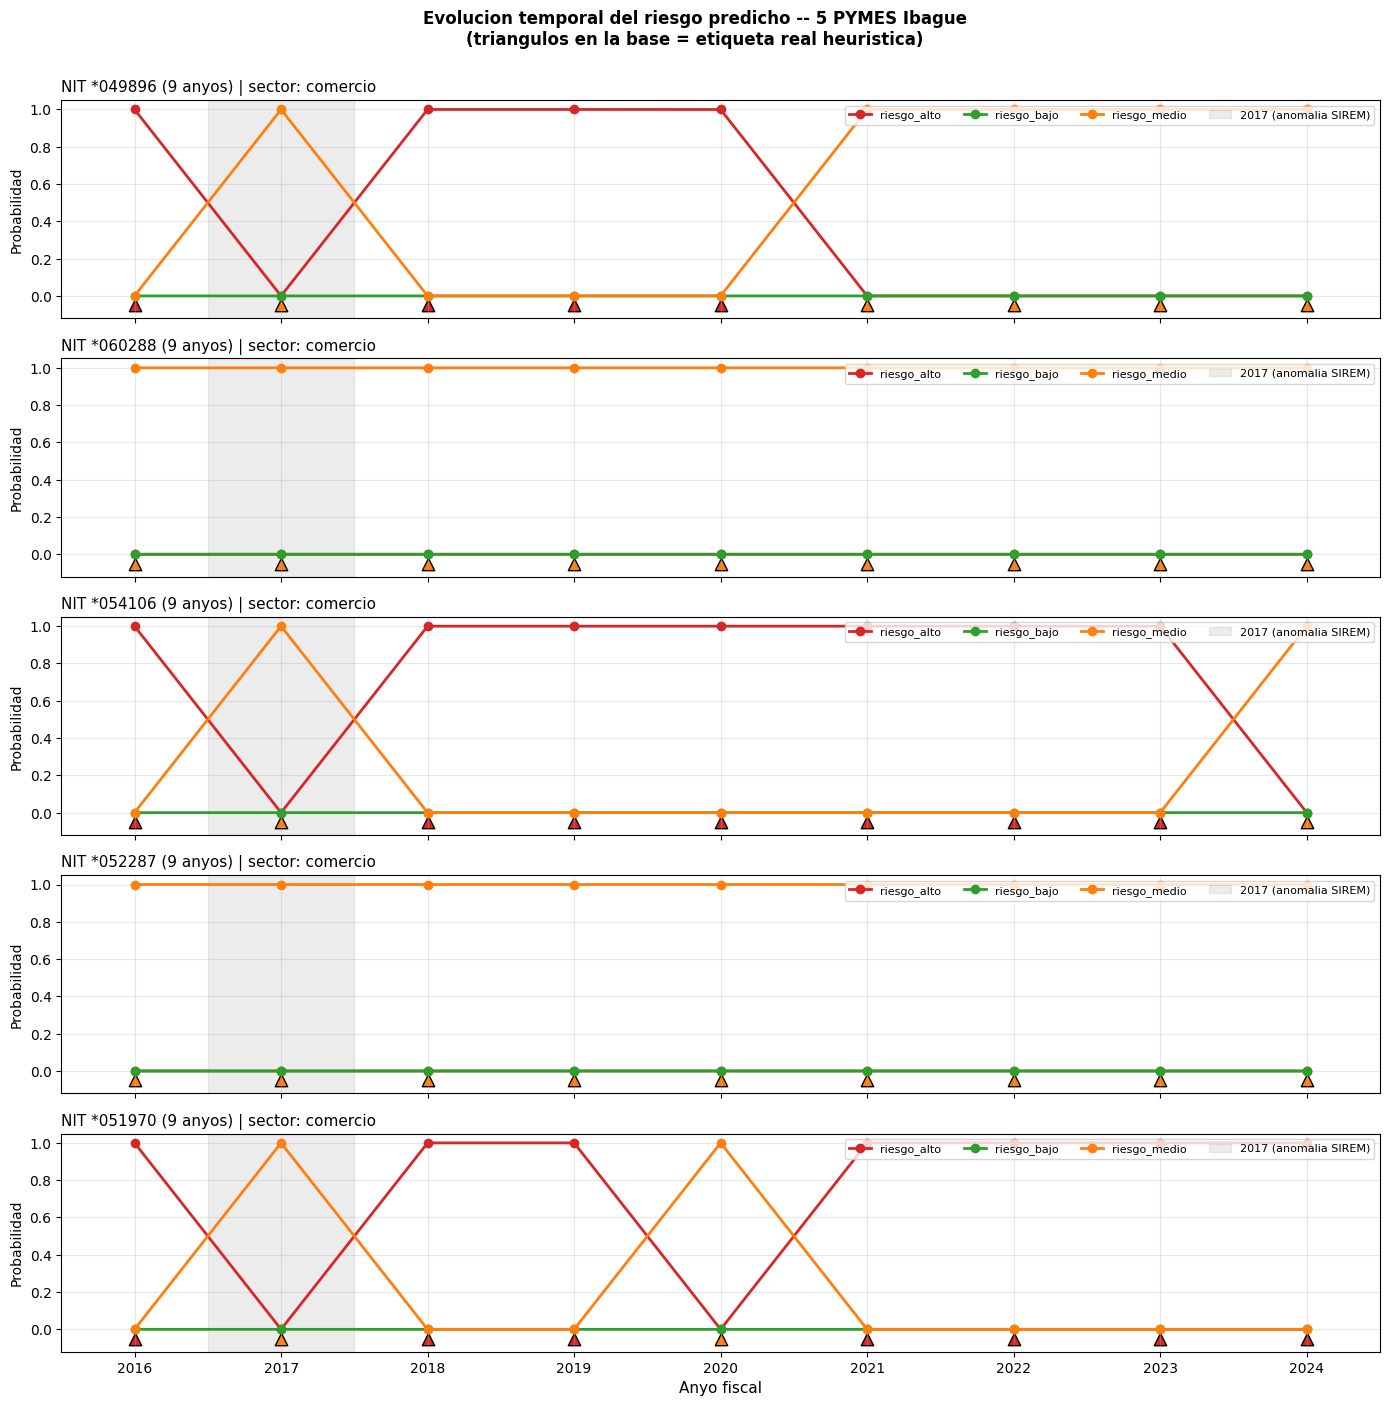


Guardado: 17_evolucion_riesgo_ibague.png


In [13]:
# 5 PYMES con mas anyos reportados
cobertura = (df_pred.groupby('NIT_LIMPIO')['ANIO']
             .nunique()
             .sort_values(ascending=False))
top_nits = cobertura.head(5).index.tolist()
print('5 PYMES con mas cobertura temporal:')
for nit in top_nits:
    n_anyos = int(cobertura[nit])
    print(f'  NIT *{str(nit)[-6:]}: {n_anyos} anyos')

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
color_clase = {'riesgo_alto': '#d62728', 'riesgo_medio': '#ff7f0e',
                'riesgo_bajo': '#2ca02c'}

for ax, nit in zip(axes, top_nits):
    sub = df_pred[df_pred['NIT_LIMPIO'] == nit].sort_values('ANIO')
    anyos = sub['ANIO'].astype(int).values
    for c in CLASSES:
        ax.plot(anyos, sub[f'prob_{c}'].values,
                marker='o', label=c, color=color_clase[c], lw=2)
    # Banda 2017
    if 2017 in anyos:
        ax.axvspan(2016.5, 2017.5, color='gray', alpha=0.15,
                    label='2017 (anomalia SIREM)')
    # Marcar etiqueta real con triangulos en la base
    for x, et in zip(anyos, sub['etiqueta_final'].values):
        ax.scatter(x, -0.05, marker='^', s=80,
                    color=color_clase[et], edgecolor='black', clip_on=False)
    nit_corto = str(nit)[-6:]
    sector = str(sub.iloc[0]['ciiu_seccion'])[:35]
    ax.set_title(f'NIT *{nit_corto} ({len(sub)} anyos) | sector: {sector}',
                  fontsize=11, loc='left')
    ax.set_ylabel('Probabilidad', fontsize=10)
    ax.set_ylim(-0.12, 1.05)
    ax.set_xlim(anyos.min() - 0.5, anyos.max() + 0.5)
    ax.set_xticks(range(int(anyos.min()), int(anyos.max()) + 1))
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=4)
axes[-1].set_xlabel('Anyo fiscal', fontsize=11)
fig.suptitle('Evolucion temporal del riesgo predicho -- 5 PYMES Ibague\n'
             '(triangulos en la base = etiqueta real heuristica)',
             fontsize=12, fontweight='bold', y=1.001)
plt.tight_layout()
fig.savefig(FIGURES / '17_evolucion_riesgo_ibague.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\nGuardado: 17_evolucion_riesgo_ibague.png')

## 11. Persistencia de outputs

- **`data/ibague/predicciones_ibague.csv`**: matriz completa de predicciones para Fase 8.
- **`reports/metrics/metricas_ibague.json`**: metricas estructuradas (subsets + por anyo + criterio 7.3).
- **`reports/tables/metricas_ibague.tex`**: tabla LaTeX para el informe (Fase 10).

In [14]:
# CSV de predicciones
cols_pred = (['NIT_LIMPIO','ANIO','etiqueta_final','prediccion','prob_max','acierto'] +
             [f'prob_{c}' for c in CLASSES] +
             ['ciiu_seccion','sociedad','departamento'])
df_pred[cols_pred].to_csv(DATA_IBAGUE / 'predicciones_ibague.csv', index=False)
print(f'Guardado: predicciones_ibague.csv ({len(df_pred)} filas, {len(cols_pred)} cols)')

# JSON metricas
metricas_json = {
    'fase': 7,
    'random_state': RANDOM_STATE,
    'modelo': 'xgboost',
    'baseline_test_nacional_f1_macro': float(F1_TEST_NACIONAL),
    'subsets': metricas_subset,
    'por_anyo': metricas_por_anyo,
    'reporte_clase_sin_2017': reporte_clase_no2017,
    'reporte_clase_todos': reporte_clase_todos,
    'distribucion_clases': {
        'nacional_test_real': dist_nac_real,
        'ibague_real_sin_2017': dist_iba_real,
        'ibague_predicho_sin_2017': dist_iba_pred,
    },
    'criterio_7_3_1': {
        'f1_macro_test_nacional': float(F1_TEST_NACIONAL),
        'f1_macro_ibague_sin_2017': float(F1_IBAGUE),
        'gap_pp': float(GAP_PP),
        'umbral_pp': 10.0,
        'pasa': bool(GAP_PP <= 10),
    },
    'errores_explicaciones': explicaciones,
    'pymes_evolucion_temporal': [
        {'NIT_LIMPIO': str(n), 'n_anyos': int(cobertura[n])} for n in top_nits],
}
with open(METRICS / 'metricas_ibague.json', 'w') as f:
    json.dump(metricas_json, f, indent=2, ensure_ascii=False)
print(f'Guardado: metricas_ibague.json')

Guardado: predicciones_ibague.csv (359 filas, 12 cols)
Guardado: metricas_ibague.json


In [15]:
# Tabla LaTeX
def fmt(x):
    return f'{x:.4f}' if x is not None else '--'

lineas = []
lineas.append(r'\begin{table}[htbp]')
lineas.append(r'\centering')
lineas.append(r'\caption{Validacion del modelo XGBoost en el holdout Ibague (61 PYMES)}')
lineas.append(r'\label{tab:metricas_ibague}')
lineas.append(r'\begin{tabular}{lrrrrr}')
lineas.append(r'\toprule')
lineas.append(r'Subconjunto & N & Accuracy & F1-macro & F1-pond. & AUC-ROC OvR \\')
lineas.append(r'\midrule')
for nombre, mtr in metricas_subset.items():
    nombre_tex = nombre.replace('_', r'\_')
    lineas.append(
        f'{nombre_tex} & {mtr["n_obs"]} & {fmt(mtr["accuracy"])} & '
        f'{fmt(mtr["f1_macro"])} & {fmt(mtr["f1_weighted"])} & '
        f'{fmt(mtr.get("auc_roc_ovr_macro"))} \\\\')
lineas.append(r'\midrule')
lineas.append(
    f'Test nacional (referencia) & {test_baseline["test_set"]["n_obs"]} & '
    f'{fmt(test_baseline["metricas_globales"]["xgboost"]["accuracy"])} & '
    f'{fmt(F1_TEST_NACIONAL)} & '
    f'{fmt(test_baseline["metricas_globales"]["xgboost"]["f1_weighted"])} & '
    f'{fmt(test_baseline["metricas_globales"]["xgboost"]["auc_roc_ovr_macro"])} \\\\')
lineas.append(r'\bottomrule')
lineas.append(r'\end{tabular}')
lineas.append(r'\end{table}')
tex = '\n'.join(lineas)
with open(TABLES / 'metricas_ibague.tex', 'w') as f:
    f.write(tex)
print(f'Guardado: metricas_ibague.tex')
print()
print(tex)

Guardado: metricas_ibague.tex

\begin{table}[htbp]
\centering
\caption{Validacion del modelo XGBoost en el holdout Ibague (61 PYMES)}
\label{tab:metricas_ibague}
\begin{tabular}{lrrrrr}
\toprule
Subconjunto & N & Accuracy & F1-macro & F1-pond. & AUC-ROC OvR \\
\midrule
ibague\_TODOS & 359 & 0.9972 & 0.9949 & 0.9972 & 1.0000 \\
ibague\_sin\_2017 & 328 & 0.9970 & 0.9948 & 0.9969 & 1.0000 \\
ibague\_solo\_2017 & 31 & 1.0000 & 1.0000 & 1.0000 & -- \\
\midrule
Test nacional (referencia) & 50957 & 0.9975 & 0.9972 & 0.9975 & 1.0000 \\
\bottomrule
\end{tabular}
\end{table}


## 12. Verificacion criterios PLAN 7.3

1. F1-macro Ibague no se degrada > 10pp respecto a test nacional.
2. Cada empresa mal clasificada tiene una explicacion plausible documentada.

In [16]:
print('--- Verificacion 1: gap F1-macro test nacional vs Ibague <= 10pp ---')
print(f'  Test nacional XGBoost: {F1_TEST_NACIONAL:.4f}')
print(f'  Ibague sin 2017      : {F1_IBAGUE:.4f}')
print(f'  Gap (pp)             : {GAP_PP:+.2f}')
print(f'  Resultado            : {"PASS" if GAP_PP <= 10 else "FAIL"}')
print()

print('--- Verificacion 2: explicacion plausible por error (5/5) ---')
todas_explicadas = all(len(e['razones']) > 0 for e in explicaciones)
for e in explicaciones:
    nit_corto = str(e['NIT_LIMPIO'])[-6:]
    estado = 'OK' if e['razones'] else 'FALTA'
    print(f'  NIT *{nit_corto} ({e["ANIO"]}): {estado} -- {len(e["razones"])} razones')
print(f'  Resultado: {"PASS" if todas_explicadas else "FAIL"}')

--- Verificacion 1: gap F1-macro test nacional vs Ibague <= 10pp ---
  Test nacional XGBoost: 0.9972
  Ibague sin 2017      : 0.9948
  Gap (pp)             : +0.24
  Resultado            : PASS

--- Verificacion 2: explicacion plausible por error (5/5) ---
  NIT *043005 (2024): OK -- 3 razones
  Resultado: PASS


## 13. Resumen Fase 7

| Item | Valor |
|---|---|
| Holdout Ibague | 61 NITs / 359 obs (2016-2024, incluye 2017) |
| Modelo evaluado | XGBoost (best_iteration=221) |
| F1-macro test nacional (referencia) | 0.9972 |
| F1-macro Ibague sin 2017 | (ver `metricas_ibague.json`) |
| Gap pp | (ver criterio 7.3 #1) |
| 5 errores documentados | si (ver `errores_explicaciones` en JSON) |

**Outputs producidos** (todos verificables en `git status`):
- `data/ibague/predicciones_ibague.csv`
- `reports/metrics/metricas_ibague.json`
- `reports/tables/metricas_ibague.tex`
- `reports/figures/14_matriz_confusion_ibague.png`
- `reports/figures/15_perfil_5_pymes_bien_clasificadas.png`
- `reports/figures/16_perfil_5_pymes_mal_clasificadas.png`
- `reports/figures/17_evolucion_riesgo_ibague.png`

**Insumos para Fase 8** (Discusion comparativa):
- `predicciones_ibague.csv` -> base para `etiquetado_manual.csv` (30 PYMES, criterio 8.1.2).
- `metricas_ibague.json` -> renglon de la tabla `comparacion_metodos` (8.1.1 vs Altman).
- Patrones de error documentados -> insumo para 8.1.4 (estabilidad sectorial).